# A) Identification of Candidate Datasets

### 1. Short-Video Addiction Dataset
- **Dataset name & source:** Can’t Stop Scrolling: Understanding the Online Behavioral Factors andTrends of Short-Video Addiction, Tsinghua FIB Lab (https://github.com/tsinghua-fib-lab/short-video-addiction)
- **Course topic alignment:**
  - Frequent Itemset Mining – frequent video/content consumption patterns
  - Large-Scale ML – predicting addiction labels from large-scale interactions
  - Clustering – segmenting users by engagement patterns
  - Text Mining – analyzing interview responses
  - Stream Mining – analyzing temporal usage patterns
- **Potential beyond-course techniques:** Sequential pattern mining, time-series modeling, graph-based user-video embeddings
- **Dataset size & structure:** 10,111 users, 1.3B user-video interactions, survey & interview labels, multi-period logs
- **Data types:** User IDs, video IDs, watch time, video category, timestamps, survey scores, interview transcripts
- **Target variable(s):** Addiction label (non-addicted, mildly addicted, severely addicted)
- **Licensing / usage constraints:** Research use, anonymized, platform-collaborated

---

### 2. Affect-Aware Cross-Domain Art Therapy Dataset
- **Dataset name & source:** Affect-aware Cross-Domain Recommendation for Art Therapy viaMusic Preference Elicitation (Music & Painting) (https://github.com/ArtAICare/Affect-aware-CDR)
- **Course topic alignment:**
  - Large-Scale ML – predicting painting preferences
  - Clustering – grouping users by emotional profiles
  - Text Mining – analyzing participant reflections
  - Graph Embeddings – learning joint music-painting embeddings
  - Hot Topics in Data Mining – multimodal affect-aware recommender systems
- **Potential beyond-course techniques:** Multimodal representation learning, contrastive learning, affective computing
- **Dataset size & structure:** 200 participants, 909 music tracks, 4,105 paintings, 239×63 similarity matrix
- **Data types:** User IDs, music features (valence/arousal), painting features (valence/arousal), similarity scores, user ratings, textual reflections
- **Target variable(s):** Preference scores, affective responses
- **Licensing / usage constraints:** Open-source research use

---

### 3. Unwanted Recommendations Dataset
- **Dataset name & source:** You Don’t Bring Me Flowers: Mitigating UnwantedRecommendations Through Conformal Risk Control (https://github.com/geektoni/mitigating-harm-recsys)
- **Course topic alignment:**
  - Large-Scale ML – training recommendation models
  - Clustering – user segmentation by reporting habits
  - Anomaly Detection – detecting unwanted content
  - Graph Embeddings – modeling user-item interactions
  - Hot Topics in Data Mining – fairness-aware recommendation
- **Potential beyond-course techniques:** Conformal prediction, distribution-free risk management, probabilistic guarantees
- **Dataset size & structure:** 5,657 users, 117,695 items, >3M interactions, repeated & single interactions
- **Data types:** User IDs, item IDs, binary feedback (safe/unsafe), timestamps
- **Target variable(s):** Fraction of unwanted content per user
- **Licensing / usage constraints:** Open-source research, dataset upon request


# B) Comparative Analysis of Candidate Datasets

| Dataset | Supported Course Tasks | Supported Beyond-Course Techniques | Data Quality Issues | Algorithmic Feasibility | Bias Considerations | Ethical Considerations |
|---------|----------------------|----------------------------------|------------------|-----------------------|------------------|---------------------|
| Short-Video Addiction | Frequent itemsets, Clustering, Text Mining, Stream Mining | Sequential pattern mining, time-series modeling, graph embeddings | Missing logs, self-report inaccuracies, temporal gaps | Large-scale ML feasible with Spark or distributed computing; sequence mining feasible | Survey participation bias; age and gender bias | Privacy of sensitive mental health data, informed consent |
| Affect-Aware Art Therapy | Clustering, Text Mining, Large-Scale ML, Graph Embeddings | Multimodal representation learning, contrastive learning | Limited sample size, uneven modality coverage, noisy self-reported reflections | Moderate size; graph embedding feasible on 200 users; multimodal embeddings computationally intensive | Sampling bias from therapeutic participants | Psychological safety; avoidance of triggering artworks; parental consent for minors |
| Unwanted Recommendations | Clustering, Anomaly Detection, Graph Embeddings | Conformal prediction, probabilistic risk guarantees | Sparse interactions, unbalanced reporting behavior | ML scalable; risk control threshold calculation feasible | Reporting bias (high vs low reporters) | Avoiding promotion of harmful recommendations; user harm minimization |


# C) Dataset Selection

**Selected Dataset:** Can't Stop Scrolling: Understanding the Onlines Behavioral Factors and Trends of Short-Video Addiction

**Reasons for selection:**
- Strong alignment with course topics: Frequent Itemsets, Clustering, Large-Scale ML, Stream Mining, Text Mining
- Supports beyond-course techniques: Sequential pattern mining, time-series analysis, graph-based user-content modeling
- Rich, large-scale dataset enables meaningful comparisons of behavior patterns
- Provides both structured (interaction logs) and unstructured data (interview transcripts)
- **Personal connection:** I relate to constantly scrolling on social media, which motivates me to study addictive patterns and engagement behaviors in a dataset I can connect with personally

**Trade-offs:**
- Sensitive mental health data requiring careful handling
- Some features (interview text) may require extensive preprocessing
- Limited geographic diversity (China-based platform)


# D) Exploratory Data Analysis

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline

In [4]:
data = pd.read_csv('dataset.csv')
data.head()

,user_id,hour_0_wt,hour_1_wt,hour_2_wt,hour_3_wt,hour_4_wt,hour_5_wt,hour_6_wt,hour_7_wt,hour_8_wt,...,gender,month_chronological_order,preds_3_label_criteria_label,preds_soft_label,watch_all_per_day_min,midnight_wt_min,morning_wt_min,noon_wt_min,afternoon_wt_min,evening_wt_min
0,31,38.500000,794.333333,90.666667,0.0,0.0,0.0,0.0,0.0,197.0,...,F,1,Severely Addicted,Addicted,27,15,5,0,43,96
1,31,748.142857,521.166667,169.500000,0.0,0.0,0.0,0.0,0.0,200.5,...,F,2,Severely Addicted,Addicted,83,23,50,23,48,68
2,31,491.307692,897.200000,901.333333,0.0,0.0,0.0,0.0,67.0,0.0,...,F,3,Severely Addicted,Addicted,82,38,38,15,39,76
3,31,0.000000,0.000000,308.000000,0.0,378.0,678.0,0.0,317.4,1174.0,...,F,4,Severely Addicted,Addicted,55,22,53,18,35,41
4,31,261.000000,490.500000,82.250000,0.0,0.0,0.0,0.0,1279.0,0.0,...,F,5,Mildly Addicted,Addicted,33,13,37,1,24,58


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       1200 non-null   int64  
 1   hour_0_wt                     1200 non-null   float64
 2   hour_1_wt                     1200 non-null   float64
 3   hour_2_wt                     1200 non-null   float64
 4   hour_3_wt                     1200 non-null   float64
 5   hour_4_wt                     1200 non-null   float64
 6   hour_5_wt                     1200 non-null   float64
 7   hour_6_wt                     1200 non-null   float64
 8   hour_7_wt                     1200 non-null   float64
 9   hour_8_wt                     1200 non-null   float64
 10  hour_9_wt                     1200 non-null   float64
 11  hour_10_wt                    1200 non-null   float64
 12  hour_11_wt                    1200 non-null   float64
 13  hou

In [6]:
data.describe()

,user_id,hour_0_wt,hour_1_wt,hour_2_wt,hour_3_wt,hour_4_wt,hour_5_wt,hour_6_wt,hour_7_wt,hour_8_wt,...,coverage_per_2weeks,category_count_unique,age,month_chronological_order,watch_all_per_day_min,midnight_wt_min,morning_wt_min,noon_wt_min,afternoon_wt_min,evening_wt_min
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,...,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,59.500000,418.365230,401.928524,334.909554,303.915727,275.928540,279.670764,301.935842,374.330768,404.648248,...,8.747083,284.959167,33.875000,5.500000,65.814167,33.117500,38.670000,13.365000,27.509167,44.992500
std,34.654256,457.835215,499.047956,502.773663,491.409614,462.197981,459.768765,400.149965,427.303470,428.803498,...,1.765762,100.644068,18.527784,2.873479,60.183259,35.781172,33.234217,12.439751,22.932433,34.077365
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.750000,13.729167,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.678571,55.809524,...,8.000000,213.750000,20.000000,3.000000,17.000000,4.000000,14.000000,3.000000,9.000000,17.000000
50%,59.500000,279.964286,220.500000,46.000000,1.071429,0.000000,14.785714,140.375000,239.963801,273.480159,...,9.333333,288.000000,31.500000,5.500000,49.000000,21.000000,31.000000,10.000000,23.000000,40.000000
75%,89.250000,675.187500,690.672222,556.350000,478.875000,401.604167,401.125000,461.458333,594.250000,605.961538,...,10.000000,358.250000,40.500000,8.000000,99.000000,50.000000,56.250000,20.000000,40.000000,66.000000
max,119.000000,2951.000000,3688.000000,3721.000000,2964.000000,3472.000000,3155.000000,2553.000000,3457.000000,2484.000000,...,13.500000,591.000000,79.000000,10.000000,365.000000,191.000000,217.000000,67.000000,131.000000,188.000000


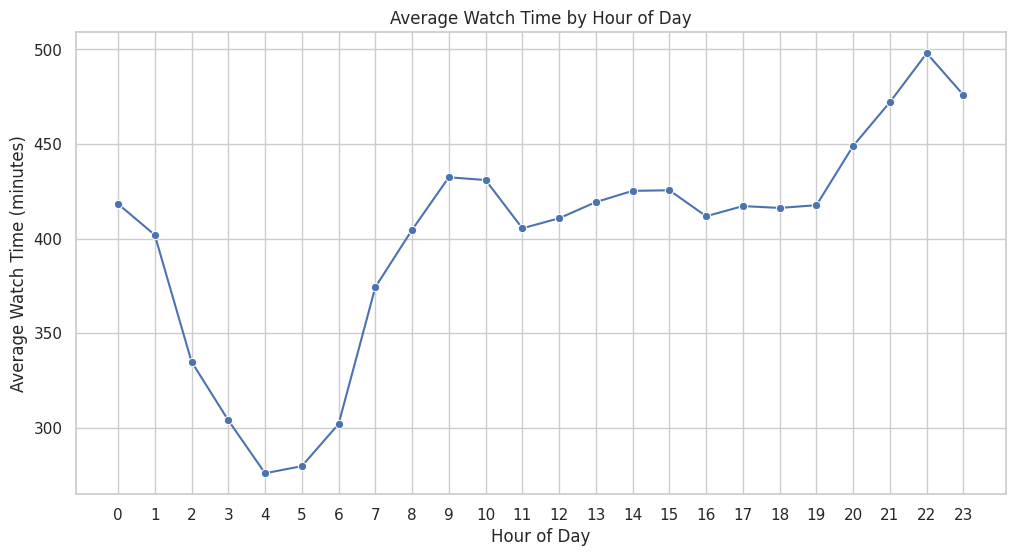

In [10]:
hourly_cols = [f'hour_{i}_wt' for i in range(24)]

hourly_avg = data[hourly_cols].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=range(24), y=hourly_avg, marker='o')
plt.title('Average Watch Time by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Watch Time (minutes)')
plt.xticks(range(24))
plt.show()


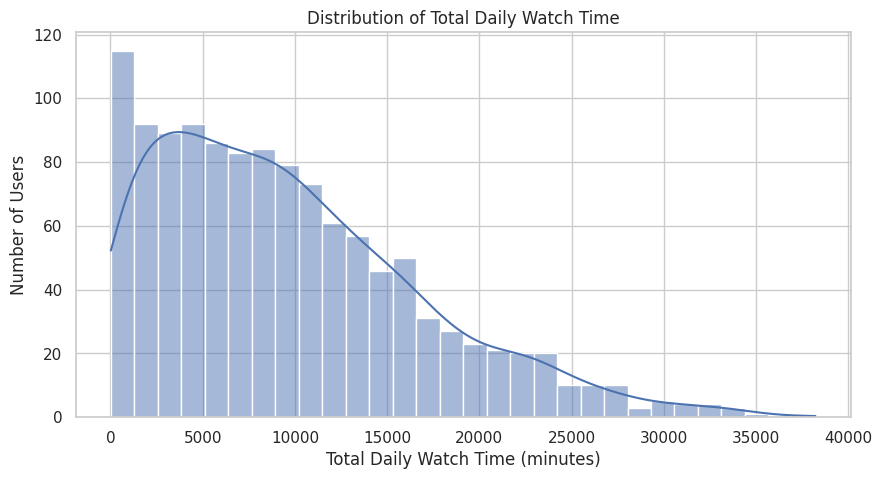

In [13]:
data['total_daily_wt'] = data[hourly_cols].sum(axis=1)

plt.figure(figsize=(10,5))
sns.histplot(data['total_daily_wt'], bins=30, kde=True)
plt.title('Distribution of Total Daily Watch Time')
plt.xlabel('Total Daily Watch Time (minutes)')
plt.ylabel('Number of Users')
plt.show()


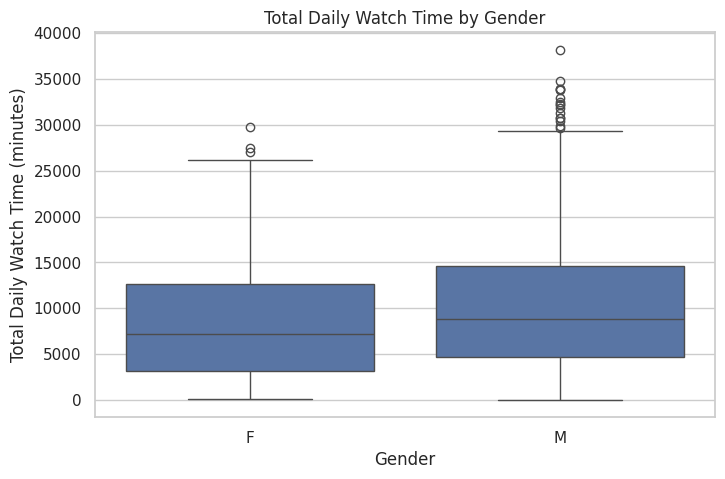

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='gender', y='total_daily_wt', data=data)
plt.title('Total Daily Watch Time by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Daily Watch Time (minutes)')
plt.show()

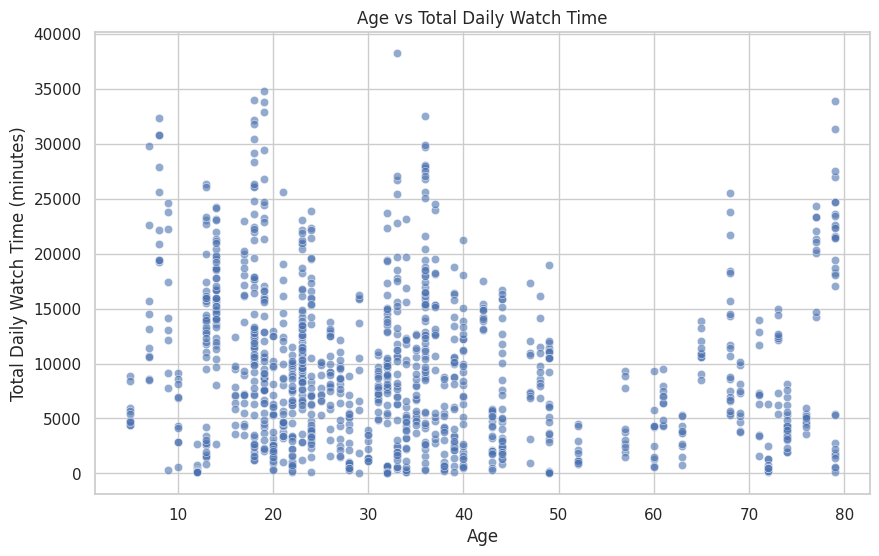

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='total_daily_wt', data=data, alpha=0.6)
plt.title('Age vs Total Daily Watch Time')
plt.xlabel('Age')
plt.ylabel('Total Daily Watch Time (minutes)')
plt.show()

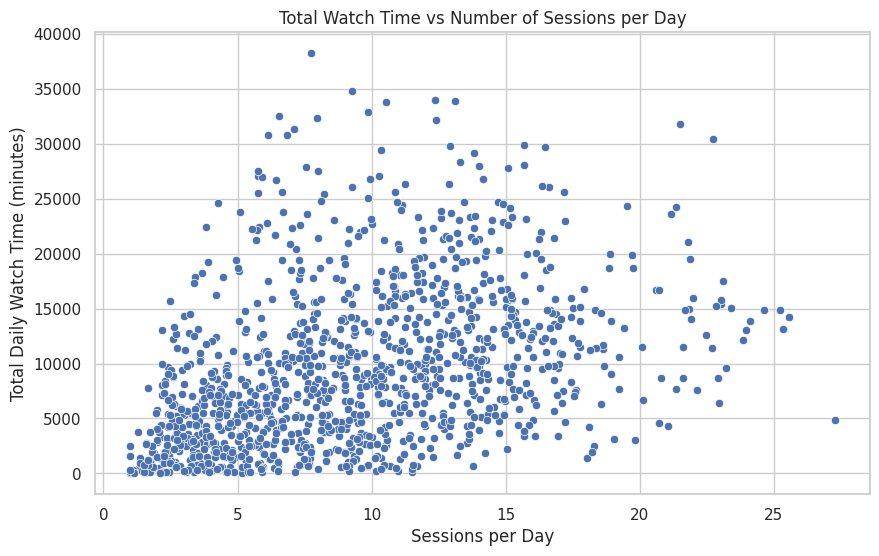

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='session_all_per_day', y='total_daily_wt', data=data)
plt.title('Total Watch Time vs Number of Sessions per Day')
plt.xlabel('Sessions per Day')
plt.ylabel('Total Daily Watch Time (minutes)')
plt.show()

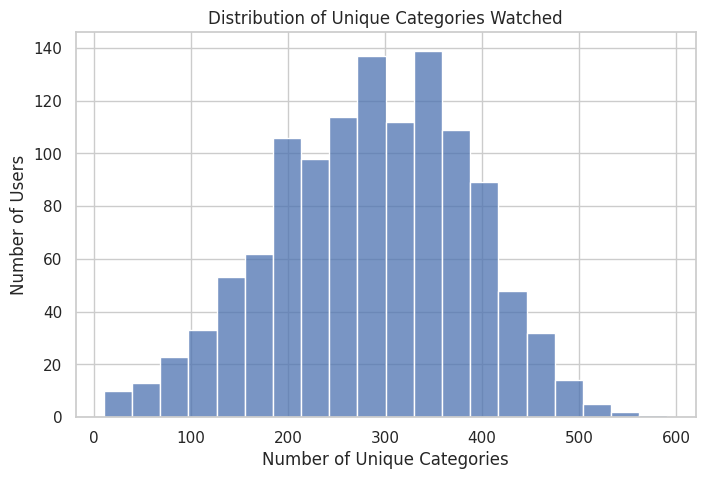

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data['category_count_unique'], bins=20, kde=False)
plt.title('Distribution of Unique Categories Watched')
plt.xlabel('Number of Unique Categories')
plt.ylabel('Number of Users')
plt.show()

I chose to create a variety of graphs because the dataset contains 41 columns and 1,200 entries. My goal is to explore and visualize as much of the data as possible. I have not performed data cleaning prior to these visualizations, but I do not expect this to significantly impact the insights from the graphs.

# E) Initial Insights and Direction

1. **Average Watch Time by Hour of Day**  
User activity peaks late at night (around 22:00 and 23:00 hours), with watch times close to or exceeding 450 minutes. Early morning and midday hours show the lowest engagement. This pattern suggests that addictive behaviors might be linked to nighttime usage, potentially impacting sleep and wellbeing.

2. **Distribution of Total Daily Watch Time**  
The distribution is heavily right-skewed, with many users watching only moderate amounts daily, but a long tail of users with very high watch times. This skew indicates that a small subset of users consumes disproportionate amounts of content, which aligns with addiction patterns seen in previous research.

3. **Total Daily Watch Time by Gender**  
The box plot highlights that males tend to have a higher median and a broader range of total daily watch times than females, with several extreme outliers exceeding 30,000 minutes per day. This gender disparity suggests engagement intensity differences and highlights the need for gender-aware analyses and interventions.

4. **Age vs. Total Daily Watch Time**  
The age distribution against watch time shows high variability across all ages but indicates clusters of heavy usage among younger users (teens and young adults). Older users tend to have lower watch times, highlighting age as a significant factor in engagement intensity and possibly addiction risk.

5. **Total Watch Time vs. Number of Sessions per Day**  
The scatterplot reveals a positive correlation between the number of daily sessions and total watch time, but with notable variability. Some users accumulate high watch times with relatively few sessions, implying long viewing periods per session, while others have many sessions but lower total watch time. This suggests that session frequency alone is insufficient to capture addiction-related behavior.

6. **Distribution of Unique Categories Watched**  
The histogram shows a broad range in the number of unique content categories users engage with, typically between 100 and 450 categories. Most users fall near the center of this range, suggesting varied but not extreme content diversity. This raises questions about how content variety might relate to addiction or filter bubble effects.

---

### Potential Research Questions

- How does the diversity of content categories watched influence addiction severity and filter bubble effects?  
- What behavioral patterns distinguish users with high watch times but low session frequency versus those with frequent sessions?  
- How do age and gender interact with temporal engagement patterns, such as late-night usage, in predicting addiction risk?  
- Can targeted interventions be designed to reduce addictive nighttime viewing without compromising user satisfaction?
- What factors contribute to higher watch times among male users compared to females?
- Can limiting usage during peak late-night hours reduce addictive behaviors without significantly impacting user satisfaction?


# (F) GitHub Portfolio Building

https://github.com/kiarasims-tamu/Short-VideoAddiction.git

On my honor, I declare the following resources:
1. Collaborators:
-

2. Web Sources:
- GitHub repo for Can't Stop Scrolling: Understanding the Onlines Behavioral Factors and Trends of Short-Video Addiction
- published papers in the notebook

3. AI Tools:
- ChatGPT - used for formatting and code